In [31]:
import re
import sys
from pathlib import Path
from typing import Any, Tuple

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
import seaborn as sns
from scipy.stats import wasserstein_distance

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import DatasetPT, load_all_synthetic_variants, pytorch_to_igraph

In [32]:
DATASET_NAMES = ["BZR", "DHFR", "Mutagenicity", "MUTAG"]
METHODS = ["dummyNodes", "dummyEdges", "padma", "anndg", "anndgE", "nextGen"]
PALETTE = {
    "dummyNodes": "#DA7CF7",
    "dummyEdges": "#98C379", 
    "padma": "#F5C431", 
    "anndg": "#E06C75",
    "anndgE": "#C47900",
    "nextGen": "#5B9BD5", 
    "_": "#5CE9FF", 
    "__": "#5242D1", 
    }
NON_TARGETED_FEATURES = ["modularity", "clustering", "assortativity", "efficiency", "diameter"]
TARGETED_FEATURES = ["n_nodes", "n_edges", 
 "degree_moments_0", "degree_moments_1", "degree_moments_2", "degree_moments_3", 
 "annd_0", "annd_1", "annd_2", "annd_3", 
 "eccentricity_0", "eccentricity_1", "eccentricity_2", "eccentricity_3"]
FEATURES = NON_TARGETED_FEATURES + TARGETED_FEATURES

def load_generation_data() -> pd.DataFrame:
    """Load and preprocess all original datasets and synthetic variants saving all per-graph statistics."""
    rows = []

    for dataset_name in DATASET_NAMES:
        # Load original
        orig_pt_path = PROJECT_ROOT / "data" / dataset_name / f"{dataset_name}_original.pt"
        if orig_pt_path.exists():
            dataset_obj = DatasetPT(orig_pt_path)
            per_graph_stats = dataset_obj.metadata.get("per_graph_statistics", [])

            for i, stats in enumerate(per_graph_stats):                
                row = {
                    "dataset": dataset_name,
                    "method": "original",
                    "type": "original",
                    "graph_idx": i,
                    "variant_idx": -1,
                    "class_id": dataset_obj[i].y.item(),
                    "seed": pd.NA,
                }
                # Flatten the stats dictionary
                if stats:
                    for key, value in stats.items():
                        if isinstance(value, (list, np.ndarray)):
                            for idx, val in enumerate(value):
                                row[f"{key}_{idx}"] = val
                        else:
                            row[key] = value
                rows.append(row)
        else:
            print(f"Warning: Original dataset not found at {orig_pt_path}")
            
        # Load synthetic variants
        for method in METHODS:
            method_dir = PROJECT_ROOT / "synthetic_data" / dataset_name / method
            if not method_dir.exists():
                continue
            
            variant_paths = load_all_synthetic_variants(method_dir, dataset_name)
            for v_idx, v_path in enumerate(variant_paths):
                dataset_obj = DatasetPT(v_path)
                per_graph_target_stats = dataset_obj.metadata.get("per_graph_target_statistics", [])
                per_graph_stats = dataset_obj.metadata.get("per_graph_statistics", [])
                seeds = dataset_obj.metadata.get("seeds", [])
                
                n_graphs = len(dataset_obj)
                for i in range(n_graphs):
                    class_id = dataset_obj[i].y.item()
                    seed = seeds[i] if (seeds and i < len(seeds)) else pd.NA
                    
                    # 1. Target Stats
                    if i < len(per_graph_target_stats):
                        t_stats = per_graph_target_stats[i]
                        row = {
                            "dataset": dataset_name,
                            "method": method,
                            "type": "target",
                            "graph_idx": i,
                            "variant_idx": v_idx,
                            "class_id": class_id,
                            "seed": seed,
                        }
                        if t_stats:
                            for key, value in t_stats.items():
                                if isinstance(value, (list, np.ndarray)):
                                    for idx, val in enumerate(value):
                                        row[f"{key}_{idx}"] = val
                                else:
                                    row[key] = value
                        rows.append(row)
                        
                    # 2. Synthetic Stats
                    if i < len(per_graph_stats):
                        s_stats = per_graph_stats[i]
                        row = {
                            "dataset": dataset_name,
                            "method": method,
                            "type": "synthetic",
                            "graph_idx": i,
                            "variant_idx": v_idx,
                            "class_id": class_id,
                            "seed": seed,
                        }
                        if s_stats:
                            for key, value in s_stats.items():
                                if isinstance(value, (list, np.ndarray)):
                                    for idx, val in enumerate(value):
                                        row[f"{key}_{idx}"] = val
                                else:
                                    row[key] = value
                        rows.append(row)
    df = pd.DataFrame(rows)
    if "seed" in df.columns:
        df["seed"] = df["seed"].astype("Int64")
    return df

# Load data
df = load_generation_data()
display(df[df["method"]=="padma"])

,dataset,method,type,graph_idx,variant_idx,class_id,seed,n_nodes,n_edges,modularity,...,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
40500,Mutagenicity,padma,target,0,0,0,1989716755,36,34,NaN,...,0.891323,1.096816,0.085714,0.080792,0.068862,0.074881,0.285638,0.220515,0.262672,0.146812
40501,Mutagenicity,padma,synthetic,0,0,0,1989716755,36,35,0.642857,...,0.815394,1.975413,0.101587,0.079365,0.069312,0.070635,0.212698,0.142857,0.152381,0.161905
40502,Mutagenicity,padma,target,1,0,1,259981607,39,38,NaN,...,-0.315698,5.398773,0.083609,0.096791,0.058727,0.059699,0.205385,0.267051,0.227910,0.106147
40503,Mutagenicity,padma,synthetic,1,0,1,259981607,39,39,0.571663,...,0.228432,3.963506,0.078947,0.070724,0.073465,0.074013,0.259868,0.240132,0.240132,0.207237
40504,Mutagenicity,padma,target,2,0,1,1738770133,18,19,NaN,...,0.364720,1.299946,0.194242,0.235294,0.150563,0.143584,0.470364,0.371416,0.259204,0.496829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60495,Mutagenicity,padma,synthetic,497,19,0,90799968,19,19,0.527701,...,-0.241978,2.045956,0.177778,0.152778,0.143519,0.134259,0.455556,0.361111,0.388889,0.319444
60496,Mutagenicity,padma,target,498,19,0,1531085963,33,35,NaN,...,0.137126,1.489424,0.117526,0.115805,0.075957,0.072298,0.341234,0.107504,0.171474,0.184994
60497,Mutagenicity,padma,synthetic,498,19,0,1531085963,33,36,0.631559,...,0.172322,1.459308,0.083333,0.103516,0.082031,0.081706,0.145833,0.214844,0.183594,0.199219
60498,Mutagenicity,padma,target,499,19,1,2038587391,26,26,NaN,...,1.709853,1.611992,0.160000,0.138081,0.094558,0.089517,0.279645,0.660320,0.403075,0.472008


In [33]:
def compute_target_synthetic_errors(df_dataset: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """Computes absolute errors between target and synthetic targeted features.

    Args:
        df_dataset: A DataFrame containing original, target, and synthetic stats.
        dataset_name: The name of the dataset to filter and analyze.
    Returns:
        A DataFrame with computed absolute errors for targeted metrics.
    Raises:
        ValueError: If no target or synthetic records are found for the dataset.
    """
    df_subset = df_dataset[df_dataset["dataset"] == dataset_name]

    df_target = df_subset[df_subset["type"] == "target"]
    df_synth = df_subset[df_subset["type"] == "synthetic"]

    if df_target.empty or df_synth.empty:
        raise ValueError(f"No target or synthetic records found for dataset: {dataset_name}")

    keys = ["graph_idx", "method", "variant_idx"]
    df_target = df_target.set_index(keys)
    df_synth = df_synth.set_index(keys)

    # Align rows to ensure exact target-synthetic comparison
    common_idx = df_target.index.intersection(df_synth.index)
    if common_idx.empty:
        raise ValueError(f"No matching target-synthetic index pairs found for dataset: {dataset_name}")

    df_target = df_target.loc[common_idx]
    df_synth = df_synth.loc[common_idx]

    # Restrict errors to TARGETED_FEATURES present in the DataFrame
    active_features = [f for f in TARGETED_FEATURES if f in df_subset.columns]

    df_errors = (df_target[active_features] - df_synth[active_features]).abs()

    # Re-insert identifying metadata
    df_errors.insert(0, "dataset", dataset_name)
    df_errors.reset_index(inplace=True)
    df_errors["class_id"] = df_synth["class_id"].values

    if "seed" in df_synth.columns:
        df_errors["seed"] = df_synth["seed"].values

    return df_errors


def aggregate_and_display_errors(df_errors: pd.DataFrame) -> None:
    """Aggregates and prints target-synthetic errors by dataset and method."""
    # Ensure method column follows standard METHODS ordered category
    df_errors = df_errors.copy()
    df_errors["method"] = pd.Categorical(df_errors["method"], categories=METHODS, ordered=True)

    active_features = [f for f in TARGETED_FEATURES if f in df_errors.columns]

    print("\n" + "=" * 80)
    print("TARGET-SYNTHETIC ERROR BY DATASET AND METHOD (Mean & Std)")
    print("=" * 80)
    detailed_summary = df_errors.groupby(["dataset", "method"], observed=True)[active_features].agg(["mean", "std"])
    with pd.option_context("display.max_columns", None):
        display(detailed_summary)

    print("\n" + "=" * 80)
    print("GLOBAL TARGET-SYNTHETIC ERROR BY METHOD (Mean & Std)")
    print("=" * 80)
    global_summary = df_errors.groupby("method", observed=True)[active_features].agg(["mean", "std"])
    with pd.option_context("display.max_columns", None):
        display(global_summary)

all_errors = []

for dataset in DATASET_NAMES:
    try:
        df_err = compute_target_synthetic_errors(df, dataset)
        all_errors.append(df_err)
    except ValueError as e:
        print(f"Skipping dataset '{dataset}': {e}")
    except Exception as e:
        print(f"Unexpected error processing '{dataset}': {e}")

if all_errors:
    df_all_errors = pd.concat(all_errors, ignore_index=True)
    aggregate_and_display_errors(df_all_errors)
else:
    print("No target-synthetic error data found across any datasets.")

Skipping dataset 'BZR': No target or synthetic records found for dataset: BZR
Skipping dataset 'DHFR': No target or synthetic records found for dataset: DHFR
Skipping dataset 'MUTAG': No target or synthetic records found for dataset: MUTAG

TARGET-SYNTHETIC ERROR BY DATASET AND METHOD (Mean & Std)


n_nodes       n_edges             degree_moments_0  \
                           mean  std     mean         std             mean   
dataset      method                                                          
Mutagenicity dummyNodes     0.0  0.0  46.5746  220.569898         0.095709   
             dummyEdges     0.0  0.0   0.0000    0.000000         0.001402   
             padma          0.0  0.0   0.2122    0.409619         0.002314   

                                  degree_moments_1           degree_moments_2  \
                              std             mean       std             mean   
dataset      method                                                             
Mutagenicity dummyNodes  0.536931         0.007627  0.014462         0.645563   
             dummyEdges  0.003729         0.002022  0.005734         0.587802   
             padma       0.010032         0.000868  0.005926         0.186406   

                                  degree_moments_3              annd_0  \
                              std             mean       std      mean   
dataset      method                                                      
Mutagenicity dummyNodes  0.552029         1.939635  1.836572  0.185399   
             dummyEdges  0.456003         1.840065  1.280486  0.122358   
             padma       0.250425         0.544977  0.586218  0.031753   

                                     annd_1              annd_2            \
                              std      mean       std      mean       std   
dataset      method                                                         
Mutagenicity dummyNodes  0.230187  0.184425  0.228870  0.178063  0.230827   
             dummyEdges  0.165810  0.121462  0.165373  0.112133  0.162286   
             padma       0.042115  0.033693  0.043070  0.021657  0.035136   

                           annd_3           eccentricity_0            \
                             mean       std           mean       std   
dataset      method                                                    
Mutagenicity dummyNodes  0.146154  0.205558       0.185966  0.120585   
             dummyEdges  0.070459  0.071835       0.150839  0.113040   
             padma       0.021189  0.036150       0.219809  0.380051   

                        eccentricity_1           eccentricity_2            \
                                  mean       std           mean       std   
dataset      method                                                         
Mutagenicity dummyNodes       0.185549  0.121671       0.152528  0.109081   
             dummyEdges       0.142652  0.108635       0.116458  0.097284   
             padma            0.219284  0.378474       0.192918  0.357079   

                        eccentricity_3            
                                  mean       std  
dataset      method                               
Mutagenicity dummyNodes       0.147294  0.090483  
             dummyEdges       0.107924  0.077446  
             padma            0.198415  0.357622


GLOBAL TARGET-SYNTHETIC ERROR BY METHOD (Mean & Std)


n_nodes       n_edges             degree_moments_0            \
              mean  std     mean         std             mean       std   
method                                                                    
dummyNodes     0.0  0.0  46.5746  220.569898         0.095709  0.536931   
dummyEdges     0.0  0.0   0.0000    0.000000         0.001402  0.003729   
padma          0.0  0.0   0.2122    0.409619         0.002314  0.010032   

           degree_moments_1           degree_moments_2            \
                       mean       std             mean       std   
method                                                             
dummyNodes         0.007627  0.014462         0.645563  0.552029   
dummyEdges         0.002022  0.005734         0.587802  0.456003   
padma              0.000868  0.005926         0.186406  0.250425   

           degree_moments_3              annd_0              annd_1            \
                       mean       std      mean       std      mean       std   
method                                                                          
dummyNodes         1.939635  1.836572  0.185399  0.230187  0.184425  0.228870   
dummyEdges         1.840065  1.280486  0.122358  0.165810  0.121462  0.165373   
padma              0.544977  0.586218  0.031753  0.042115  0.033693  0.043070   

              annd_2              annd_3           eccentricity_0            \
                mean       std      mean       std           mean       std   
method                                                                        
dummyNodes  0.178063  0.230827  0.146154  0.205558       0.185966  0.120585   
dummyEdges  0.112133  0.162286  0.070459  0.071835       0.150839  0.113040   
padma       0.021657  0.035136  0.021189  0.036150       0.219809  0.380051   

           eccentricity_1           eccentricity_2           eccentricity_3  \
                     mean       std           mean       std           mean   
method                                                                        
dummyNodes       0.185549  0.121671       0.152528  0.109081       0.147294   
dummyEdges       0.142652  0.108635       0.116458  0.097284       0.107924   
padma            0.219284  0.378474       0.192918  0.357079       0.198415   

                      
                 std  
method                
dummyNodes  0.090483  
dummyEdges  0.077446  
padma       0.357622

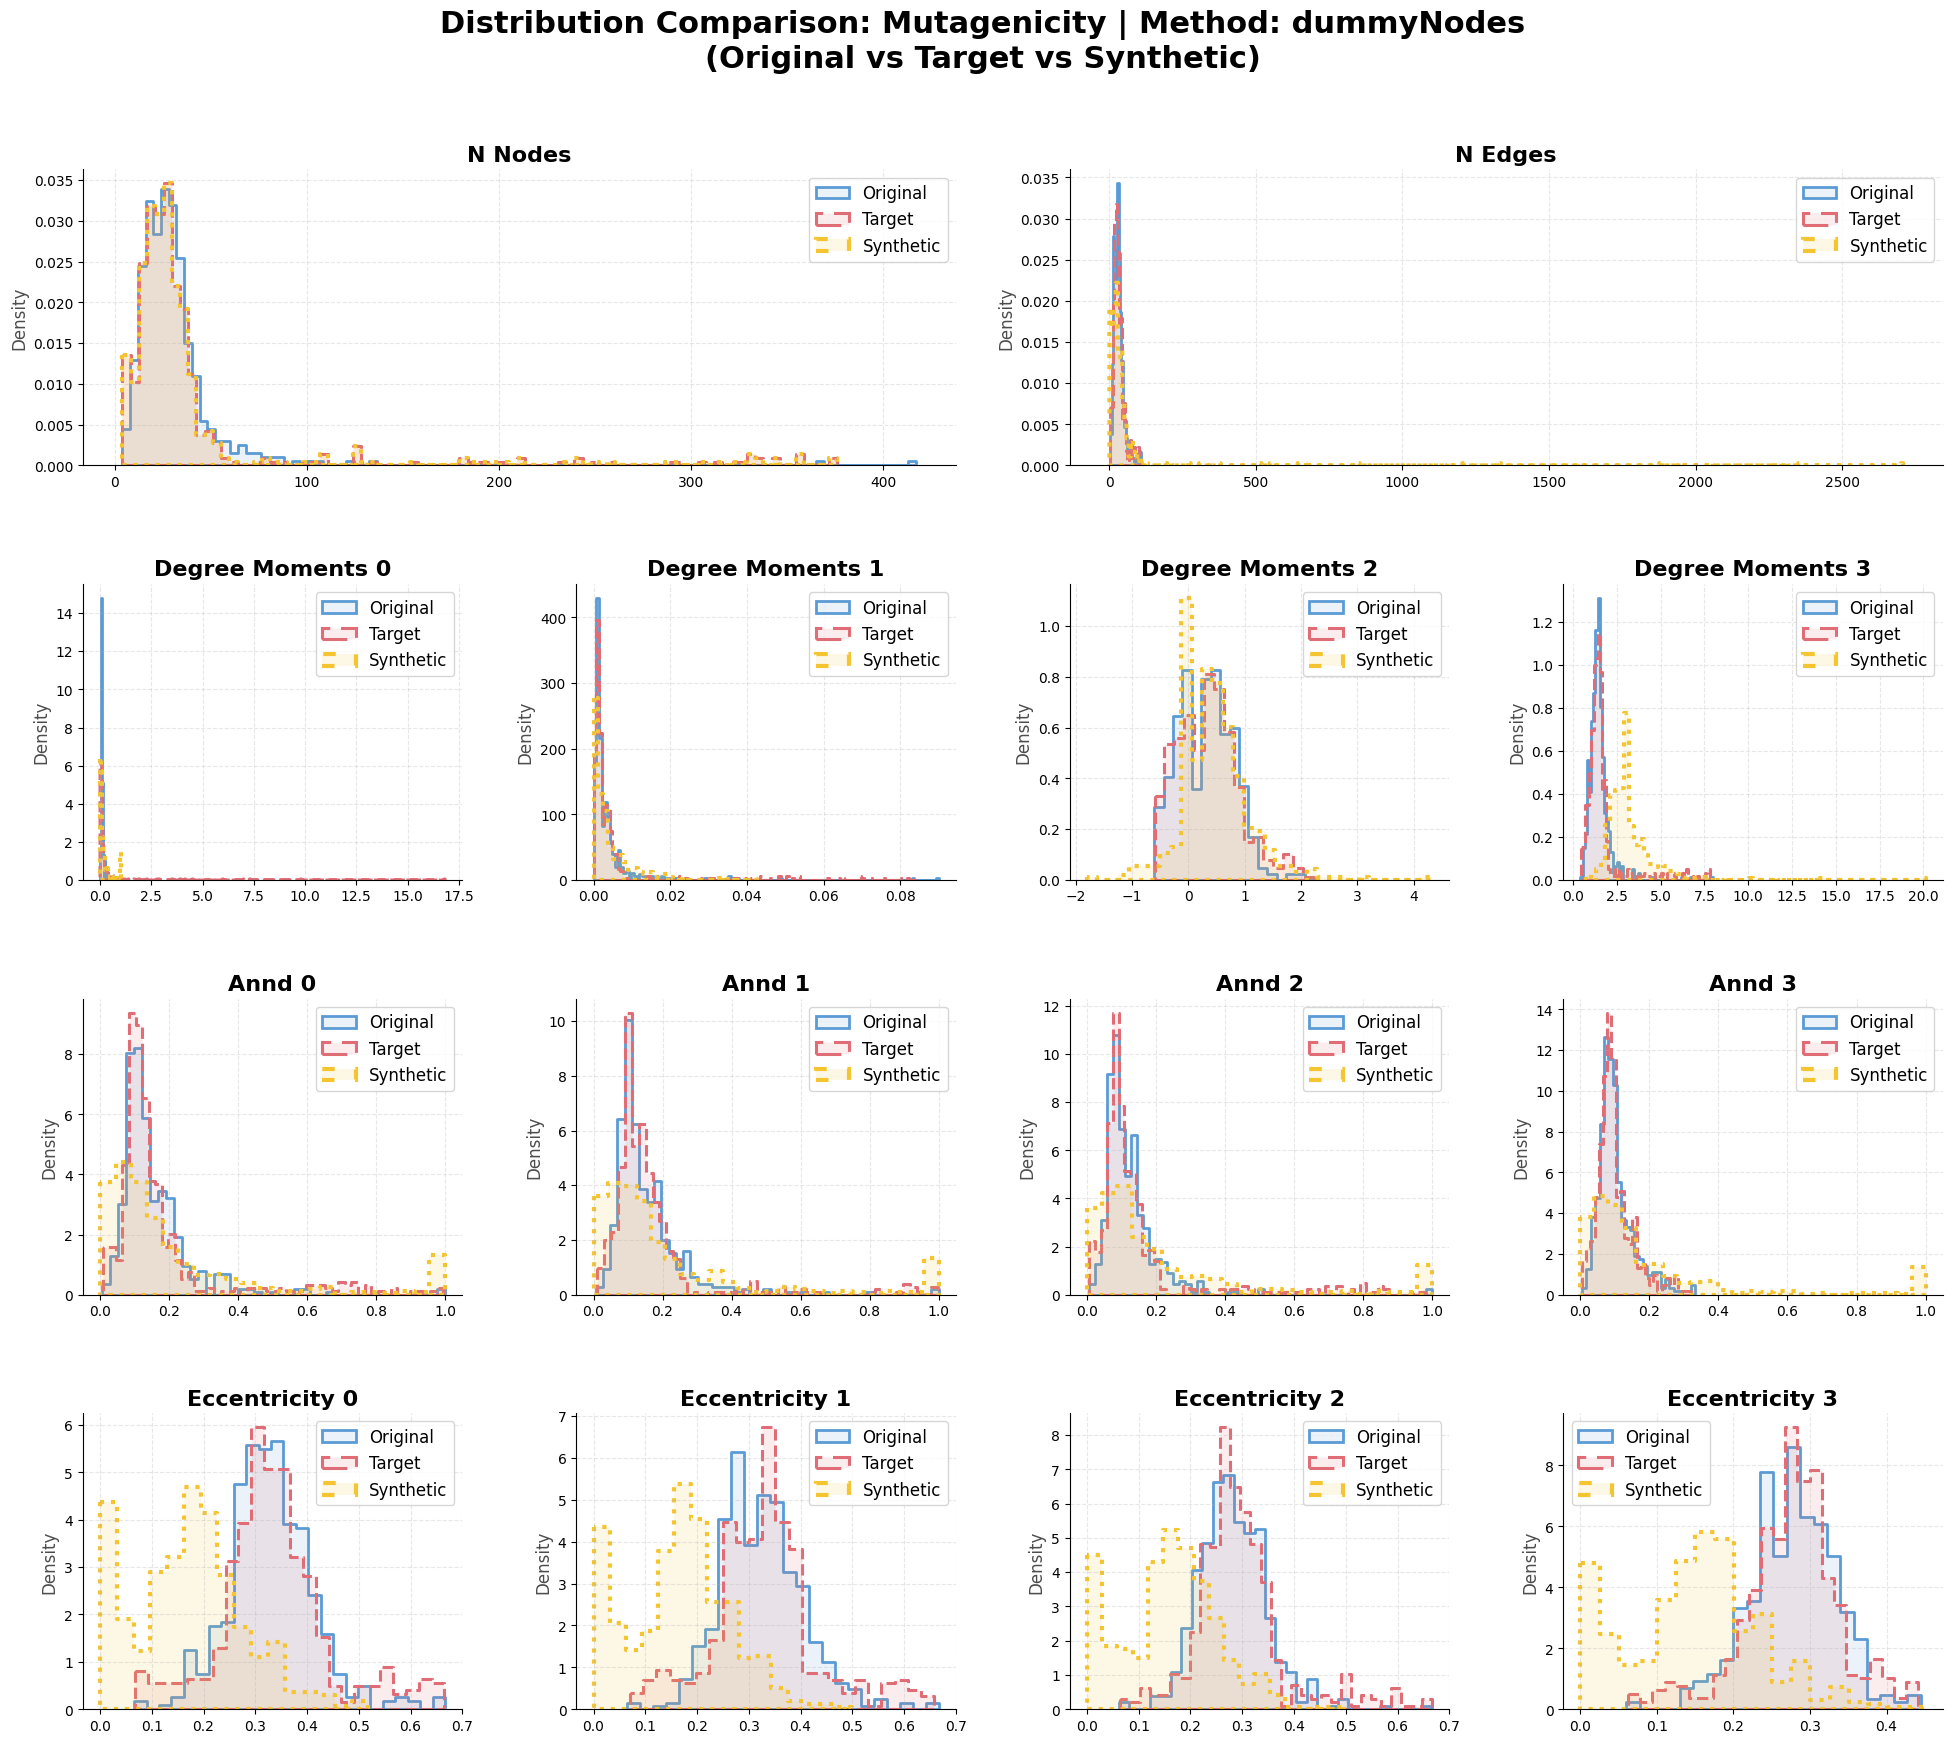


WASSERSTEIN DISTANCES - METHOD: dummyNodes


n_nodes   n_edges  degree_moments_0  degree_moments_1  \
Mutagenicity target     0.03597  0.017600          0.328220          0.033252   
             synthetic  0.03597  0.390252          0.196333          0.016202   
MEAN         target     0.03597  0.017600          0.328220          0.033252   
             synthetic  0.03597  0.390252          0.196333          0.016202   

                        degree_moments_2  degree_moments_3    annd_0   annd_1  \
Mutagenicity target             0.020409          0.026631  0.029402  0.02953   
             synthetic          0.044941          0.231240  0.083973  0.08041   
MEAN         target             0.020409          0.026631  0.029402  0.02953   
             synthetic          0.044941          0.231240  0.083973  0.08041   

                          annd_2    annd_3  eccentricity_0  eccentricity_1  \
Mutagenicity target     0.032220  0.016359        0.021285        0.025029   
             synthetic  0.092551  0.310495        0.275376        0.280188   
MEAN         target     0.032220  0.016359        0.021285        0.025029   
             synthetic  0.092551  0.310495        0.275376        0.280188   

                        eccentricity_2  eccentricity_3  Global_Score  
Mutagenicity target           0.023645        0.022871      0.047316  
             synthetic        0.217541        0.352127      0.186257  
MEAN         target           0.023645        0.022871      0.047316  
             synthetic        0.217541        0.352127      0.186257

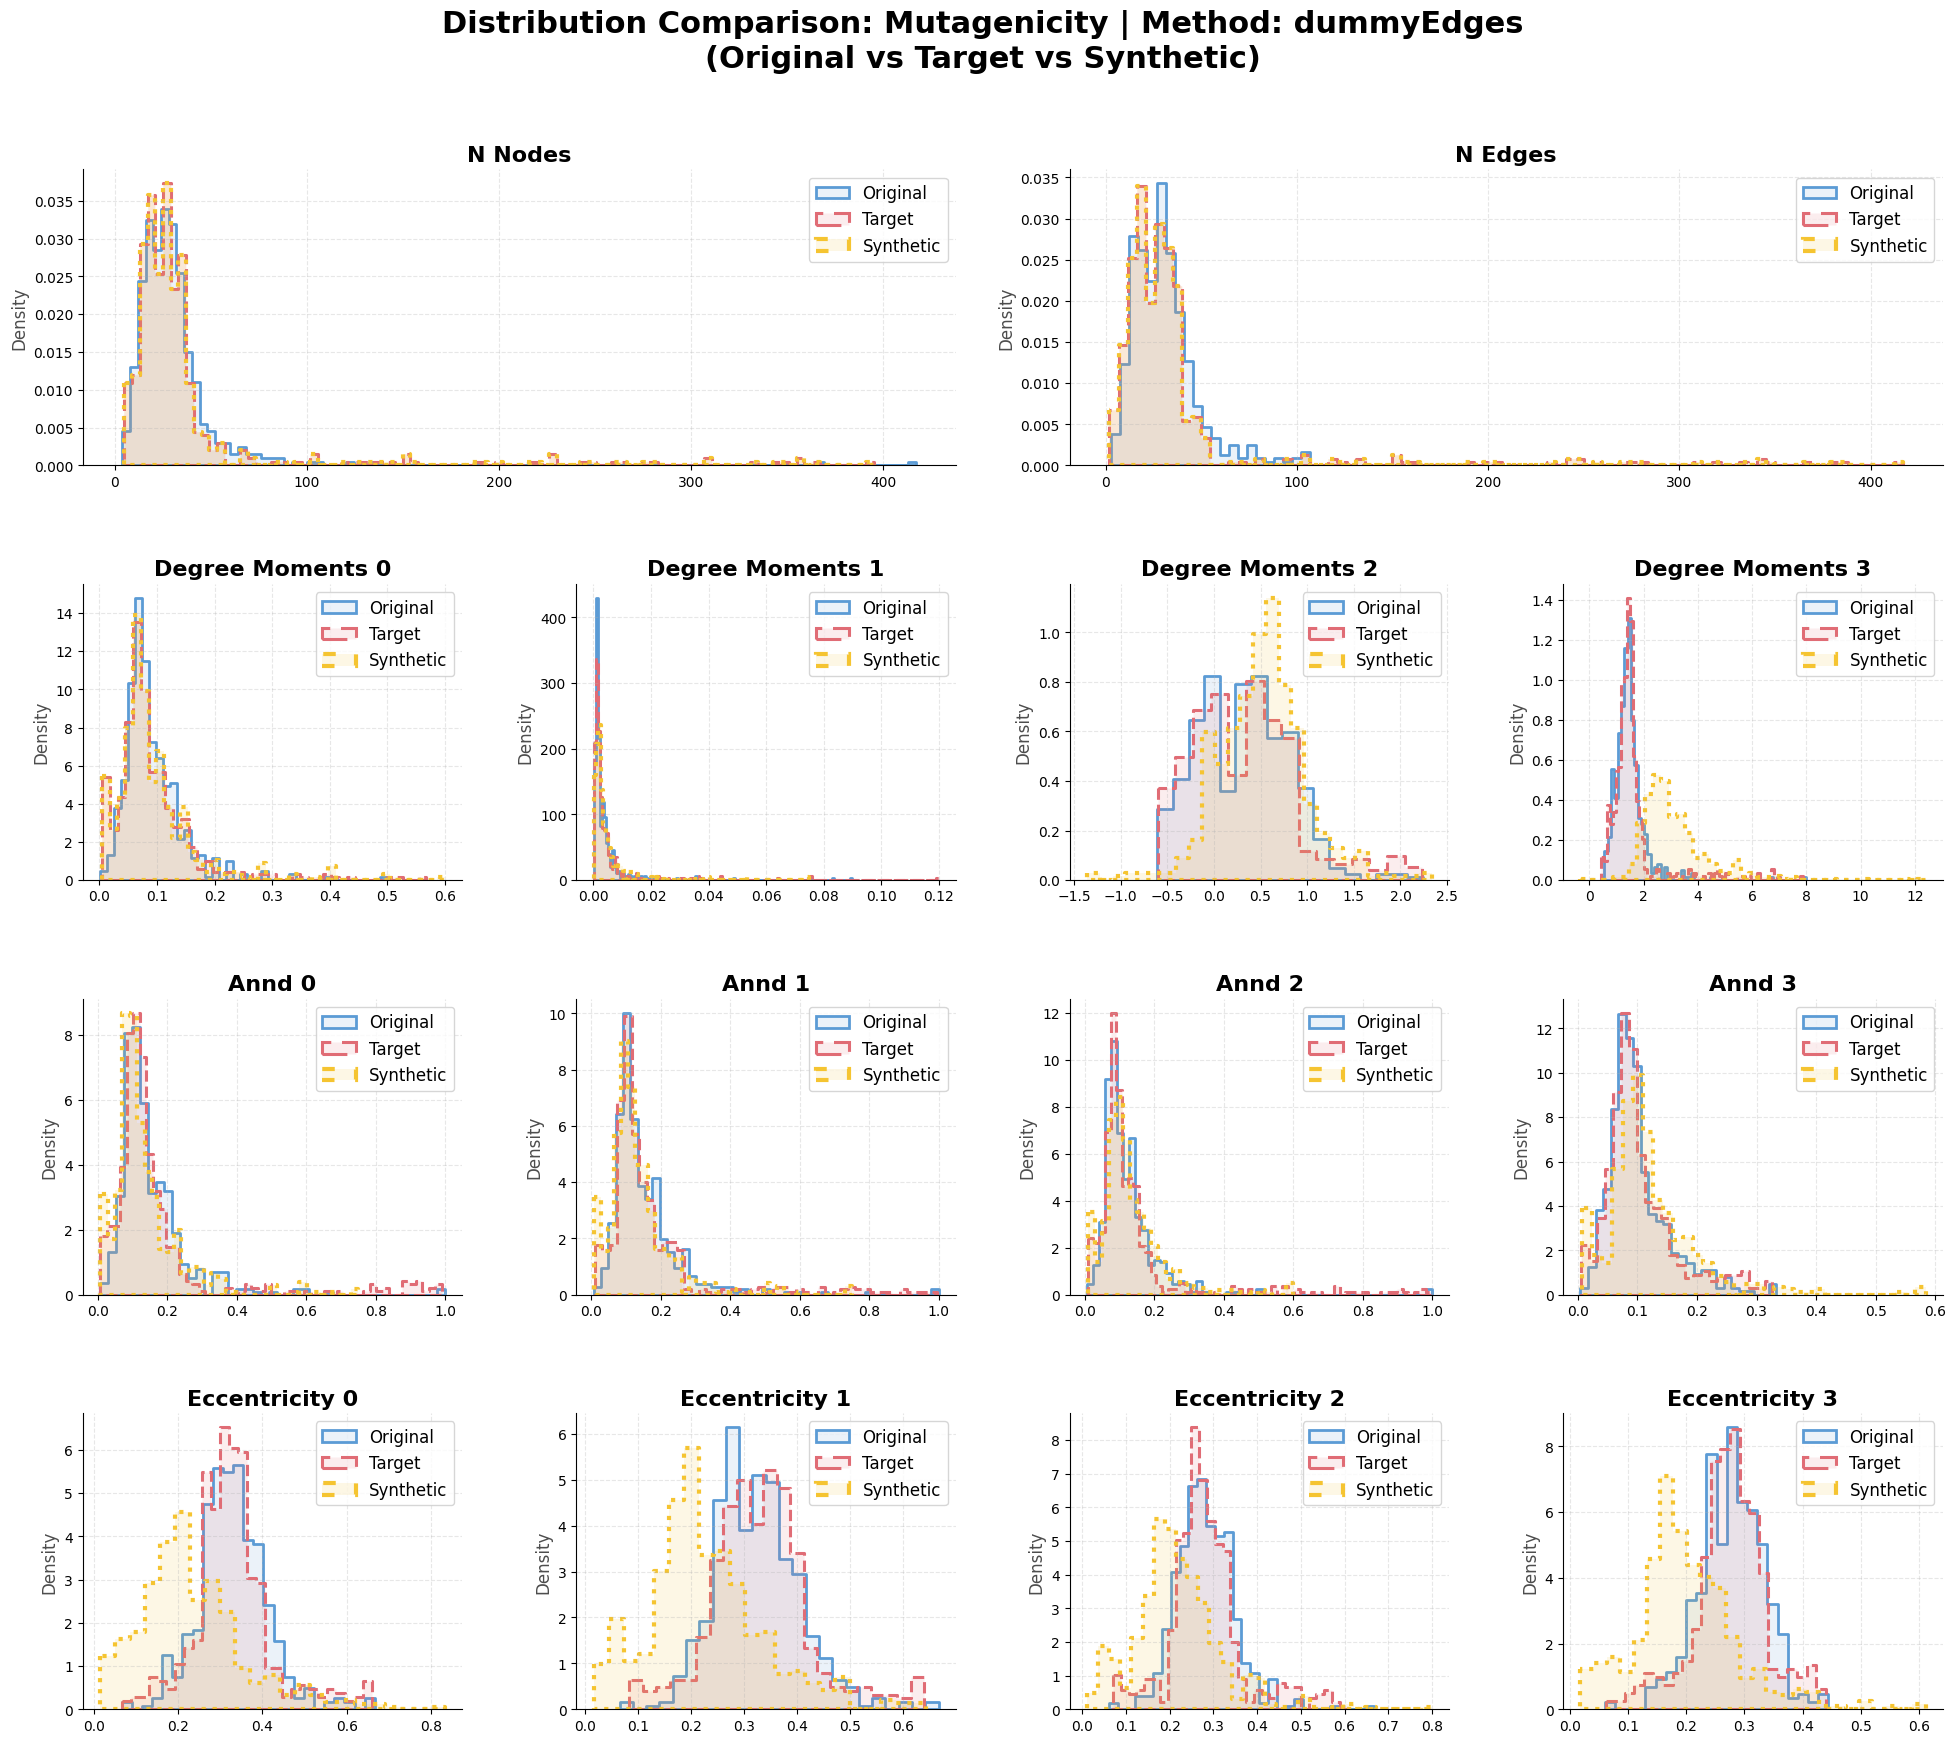


WASSERSTEIN DISTANCES - METHOD: dummyEdges


n_nodes   n_edges  degree_moments_0  \
Mutagenicity target     0.035866  0.155314          0.025006   
             synthetic  0.035866  0.155314          0.024695   
MEAN         target     0.035866  0.155314          0.025006   
             synthetic  0.035866  0.155314          0.024695   

                        degree_moments_1  degree_moments_2  degree_moments_3  \
Mutagenicity target             0.012417          0.019097          0.028127   
             synthetic          0.012102          0.062860          0.215629   
MEAN         target             0.012417          0.019097          0.028127   
             synthetic          0.012102          0.062860          0.215629   

                          annd_0    annd_1    annd_2    annd_3  \
Mutagenicity target     0.027573  0.029235  0.033005  0.016514   
             synthetic  0.021686  0.021981  0.016635  0.069156   
MEAN         target     0.027573  0.029235  0.033005  0.016514   
             synthetic  0.021686  0.021981  0.016635  0.069156   

                        eccentricity_0  eccentricity_1  eccentricity_2  \
Mutagenicity target           0.021869        0.025519        0.024786   
             synthetic        0.154443        0.151743        0.103279   
MEAN         target           0.021869        0.025519        0.024786   
             synthetic        0.154443        0.151743        0.103279   

                        eccentricity_3  Global_Score  
Mutagenicity target           0.022719      0.034075  
             synthetic        0.194718      0.088579  
MEAN         target           0.022719      0.034075  
             synthetic        0.194718      0.088579

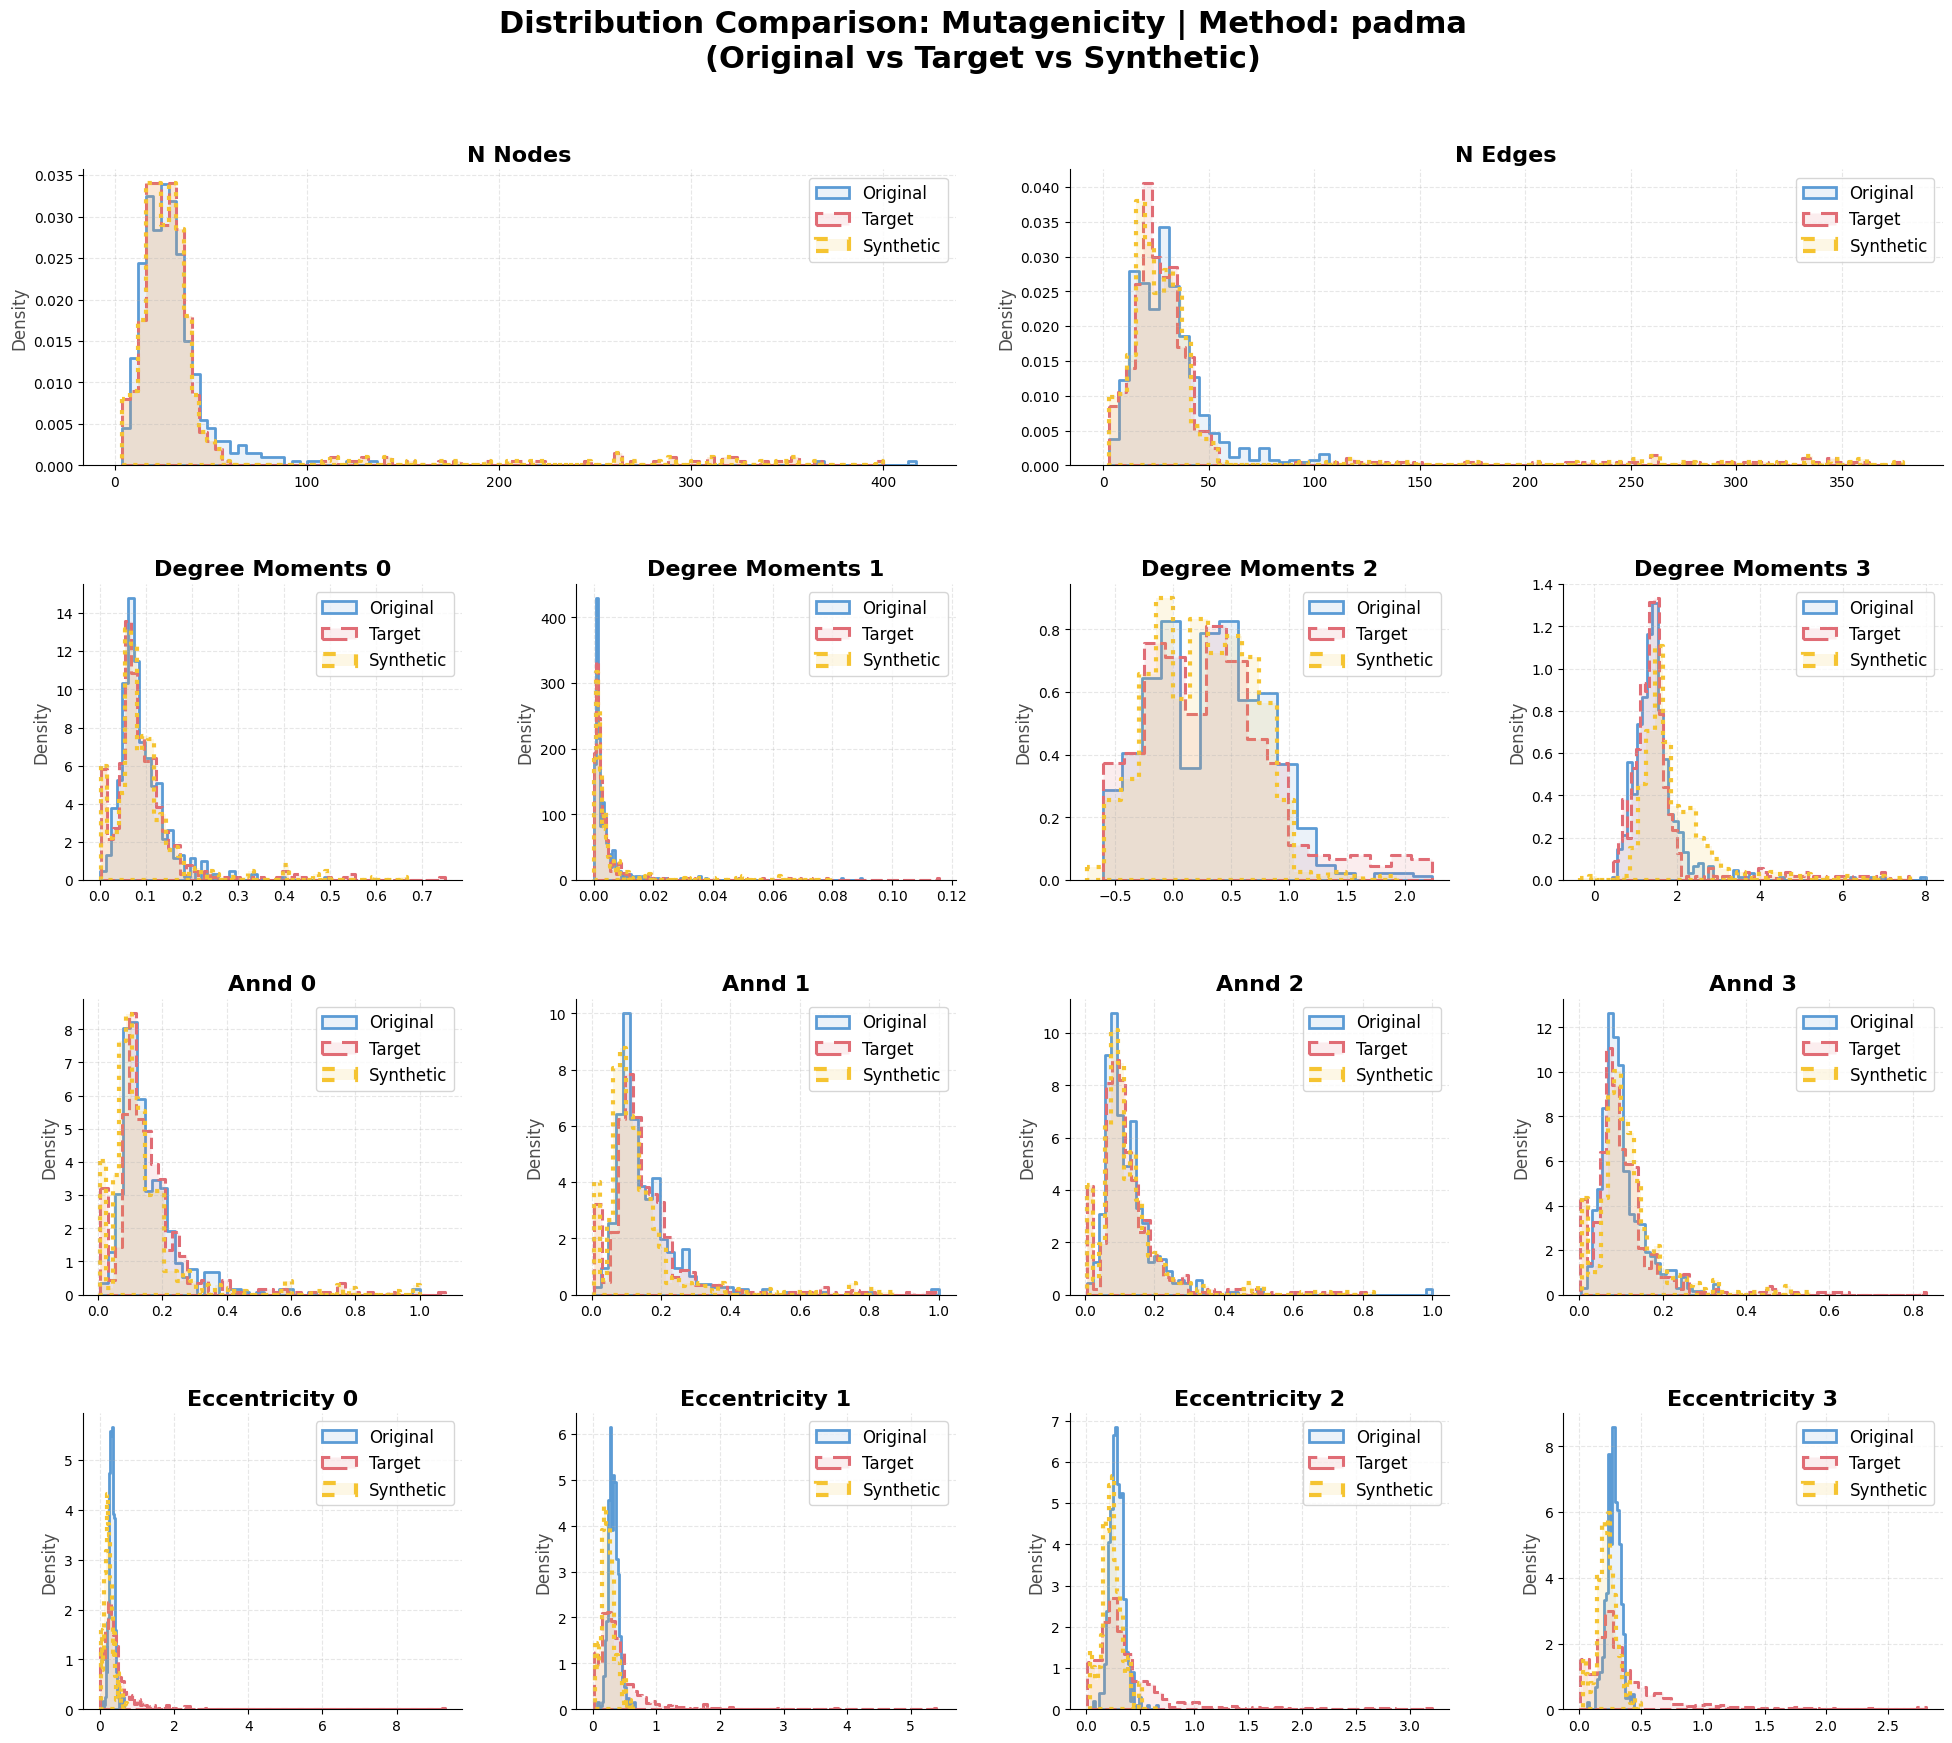


WASSERSTEIN DISTANCES - METHOD: padma


n_nodes   n_edges  degree_moments_0  \
Mutagenicity target     0.035943  0.153848          0.025558   
             synthetic  0.035943  0.152785          0.025328   
MEAN         target     0.035943  0.153848          0.025558   
             synthetic  0.035943  0.152785          0.025328   

                        degree_moments_1  degree_moments_2  degree_moments_3  \
Mutagenicity target             0.014971          0.020799          0.026398   
             synthetic          0.011777          0.019306          0.078418   
MEAN         target             0.014971          0.020799          0.026398   
             synthetic          0.011777          0.019306          0.078418   

                          annd_0    annd_1    annd_2    annd_3  \
Mutagenicity target     0.016543  0.016596  0.015849  0.048638   
             synthetic  0.028359  0.028228  0.014622  0.061592   
MEAN         target     0.016543  0.016596  0.015849  0.048638   
             synthetic  0.028359  0.028228  0.014622  0.061592   

                        eccentricity_0  eccentricity_1  eccentricity_2  \
Mutagenicity target           0.304009        0.301791        0.280784   
             synthetic        0.147396        0.141882        0.086406   
MEAN         target           0.304009        0.301791        0.280784   
             synthetic        0.147396        0.141882        0.086406   

                        eccentricity_3  Global_Score  
Mutagenicity target           0.457735      0.122819  
             synthetic        0.158463      0.070750  
MEAN         target           0.457735      0.122819  
             synthetic        0.158463      0.070750

In [34]:
def compute_wassestrain_distance(df_orig: pd.DataFrame, df_synth: pd.DataFrame, features: list[str]) -> dict[str, float]:
    """Computes the Wasserstein distance for each feature using anchored Min-Max scaling.
    
    Args:
        df_orig: Original dataset DataFrame.
        df_synth: Synthetic (or target) dataset DataFrame.
        features: List of feature names to evaluate.        
    Returns:
        A dictionary mapping feature names to their Wasserstein distance.
    """
    results: dict[str, float] = {}
    
    # Evaluate only features present in both dataframes
    valid_features = [f for f in features if f in df_orig.columns and f in df_synth.columns]
    
    for feat in valid_features:
        orig_values = df_orig[feat].dropna().values
        synth_values = df_synth[feat].dropna().values
        
        if len(orig_values) == 0 or len(synth_values) == 0:
            results[feat] = float("nan")
            continue
            
        # 1. Anchored Min-Max Scaling
        min_val = np.min(orig_values)
        max_val = np.max(orig_values)
        range_val = max_val - min_val
        
        if range_val > 0:
            orig_scaled = (orig_values - min_val) / range_val
            synth_scaled = (synth_values - min_val) / range_val
        else:
            orig_scaled = orig_values - min_val
            synth_scaled = synth_values - min_val
            
        # 2. Wasserstein Distance calculation
        dist = wasserstein_distance(orig_scaled, synth_scaled)
        results[feat] = float(dist)
        
    return results

def plot_method_dataset_comparison(df_orig: pd.DataFrame, df_target: pd.DataFrame, df_synth: pd.DataFrame, dataset_name: str, method_name: str) -> None:
    """Plots overlapping distributions of targeted metrics for original, target, and synthetic datasets."""
    features_grid = [
        ["n_nodes", "n_edges"],
        ["degree_moments_0", "degree_moments_1", "degree_moments_2", "degree_moments_3"],
        ["annd_0", "annd_1", "annd_2", "annd_3"],
        ["eccentricity_0", "eccentricity_1", "eccentricity_2", "eccentricity_3"]
    ]
    n_rows = len(features_grid)
    
    fig = plt.figure(figsize=(24, 5 * n_rows))
    fig.suptitle(
        f"Distribution Comparison: {dataset_name} | Method: {method_name}\n(Original vs Target vs Synthetic)",
        fontsize=22, fontweight="bold", y=0.96
    )
    gs = fig.add_gridspec(n_rows, 4, hspace=0.4, wspace=0.3)
    
    # Map each feature to its computed dynamic subplot
    metrics_map = []
    for r_idx, row_features in enumerate(features_grid):
        col_span = 4 // len(row_features)
        for c_idx, feat in enumerate(row_features):
            start_col = c_idx * col_span
            end_col = start_col + col_span
            ax = fig.add_subplot(gs[r_idx, start_col:end_col])
            metrics_map.append((feat, ax))
        
    plot_configs = [
        (df_orig, "Original", "#5B9BD5", "-", 2.0),
        (df_target, "Target", "#E06C75", "--", 2.2),
        (df_synth, "Synthetic", "#F5C431", ":", 3.0)
    ]
        
    for feat, ax in metrics_map:
        if feat not in df_orig.columns:
            ax.axis("off")
            continue
            
        # Plot distributions
        for data, label, color, linestyle, linewidth in plot_configs:
            if data.empty or feat not in data.columns:
                continue
            sns.histplot(
                data=data, x=feat, ax=ax, label=label,
                color=color, alpha=0.12, stat="density", element="step",
                linewidth=linewidth, linestyle=linestyle, fill=True
            )
        
        ax.set_title(feat.replace("_", " ").title(), fontsize=16, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Density", fontsize=12, alpha=0.7)
        ax.legend(fontsize=12, frameon=True, facecolor="white", framealpha=0.8)
        ax.grid(True, linestyle="--", alpha=0.3)
        sns.despine(ax=ax)
        
    plt.show()

def evaluate_distribution_distances(df_method: pd.DataFrame, method_name: str, plot_dataset: str = "MUTAG") -> None:
    """Evaluates and displays Wasserstein distances for a single method.
    
    Args:
        df_method: The DataFrame filtered for the current method (and original data).
        method_name: The name of the method being evaluated.
        plot_dataset: The name of the dataset for which to plot distributions comparison.
    """
    method_rows = []
    for dataset in DATASET_NAMES:
        df_sub = df_method[df_method["dataset"] == dataset]
        df_orig = df_sub[df_sub["type"] == "original"]
        df_target = df_sub[df_sub["type"] == "target"]
        df_synth = df_sub[df_sub["type"] == "synthetic"]
        
        if df_orig.empty:
            continue
            
        # Plot overlapping distributions comparison (only for the specified dataset and variant 0)
        if dataset == plot_dataset:
            df_target_plot = df_target[df_target["variant_idx"] == 0] if not df_target.empty else df_target
            df_synth_plot = df_synth[df_synth["variant_idx"] == 0] if not df_synth.empty else df_synth
            plot_method_dataset_comparison(df_orig, df_target_plot, df_synth_plot, dataset, method_name)
            
        # Original vs Target (Targeted features only)
        if not df_target.empty:
            variant_dists = []
            for v_idx in df_target["variant_idx"].unique():
                df_target_var = df_target[df_target["variant_idx"] == v_idx]
                if df_target_var.empty:
                    continue
                var_dist = compute_wassestrain_distance(df_orig, df_target_var, TARGETED_FEATURES)
                variant_dists.append(var_dist)
                
            if variant_dists:
                # Average the metrics across all variants
                df_vars = pd.DataFrame(variant_dists)
                t_dist = df_vars.mean(numeric_only=True).to_dict()
                t_dist["Global_Score"] = float(np.nanmean(list(t_dist.values())))
                t_dist["dataset"] = dataset
                t_dist["comparison"] = "target"
                method_rows.append(t_dist)
            
        # Original vs Synthetic (Targeted features only)
        if not df_synth.empty:
            variant_dists = []
            for v_idx in df_synth["variant_idx"].unique():
                df_synth_var = df_synth[df_synth["variant_idx"] == v_idx]
                if df_synth_var.empty:
                    continue
                var_dist = compute_wassestrain_distance(df_orig, df_synth_var, TARGETED_FEATURES)
                variant_dists.append(var_dist)
                
            if variant_dists:
                # Average the metrics across all variants
                df_vars = pd.DataFrame(variant_dists)
                s_dist = df_vars.mean(numeric_only=True).to_dict()
                s_dist["Global_Score"] = float(np.nanmean(list(s_dist.values())))
                s_dist["dataset"] = dataset
                s_dist["comparison"] = "synthetic"
                method_rows.append(s_dist)
            
    if method_rows:
        df_res = pd.DataFrame(method_rows)
        df_res.set_index(["dataset", "comparison"], inplace=True)
        
        # Reorder columns to preserve TARGETED_FEATURES ordering and append Global_Score
        cols = [c for c in TARGETED_FEATURES if c in df_res.columns] + ["Global_Score"]
        df_res = df_res[cols]
        
        # Calculate means for "target" and "synthetic" comparisons
        mean_target = df_res.xs("target", level="comparison").mean(numeric_only=True)
        mean_target.name = ("MEAN", "target")
        
        mean_synth = df_res.xs("synthetic", level="comparison").mean(numeric_only=True)
        mean_synth.name = ("MEAN", "synthetic")
        
        # Append mean rows to the DataFrame
        df_res = pd.concat([df_res, mean_target.to_frame().T, mean_synth.to_frame().T])
        
        print("\n" + "=" * 100)
        print(f"WASSERSTEIN DISTANCES - METHOD: {method_name}")
        print("=" * 100)
        with pd.option_context("display.max_columns", None):
            display(df_res)


for method in METHODS:
    df_method_subset = df[(df["method"] == method) | (df["type"] == "original")]
    
    if df_method_subset[df_method_subset["method"] == method].empty:
        continue
        
    evaluate_distribution_distances(df_method_subset, method, plot_dataset="Mutagenicity")

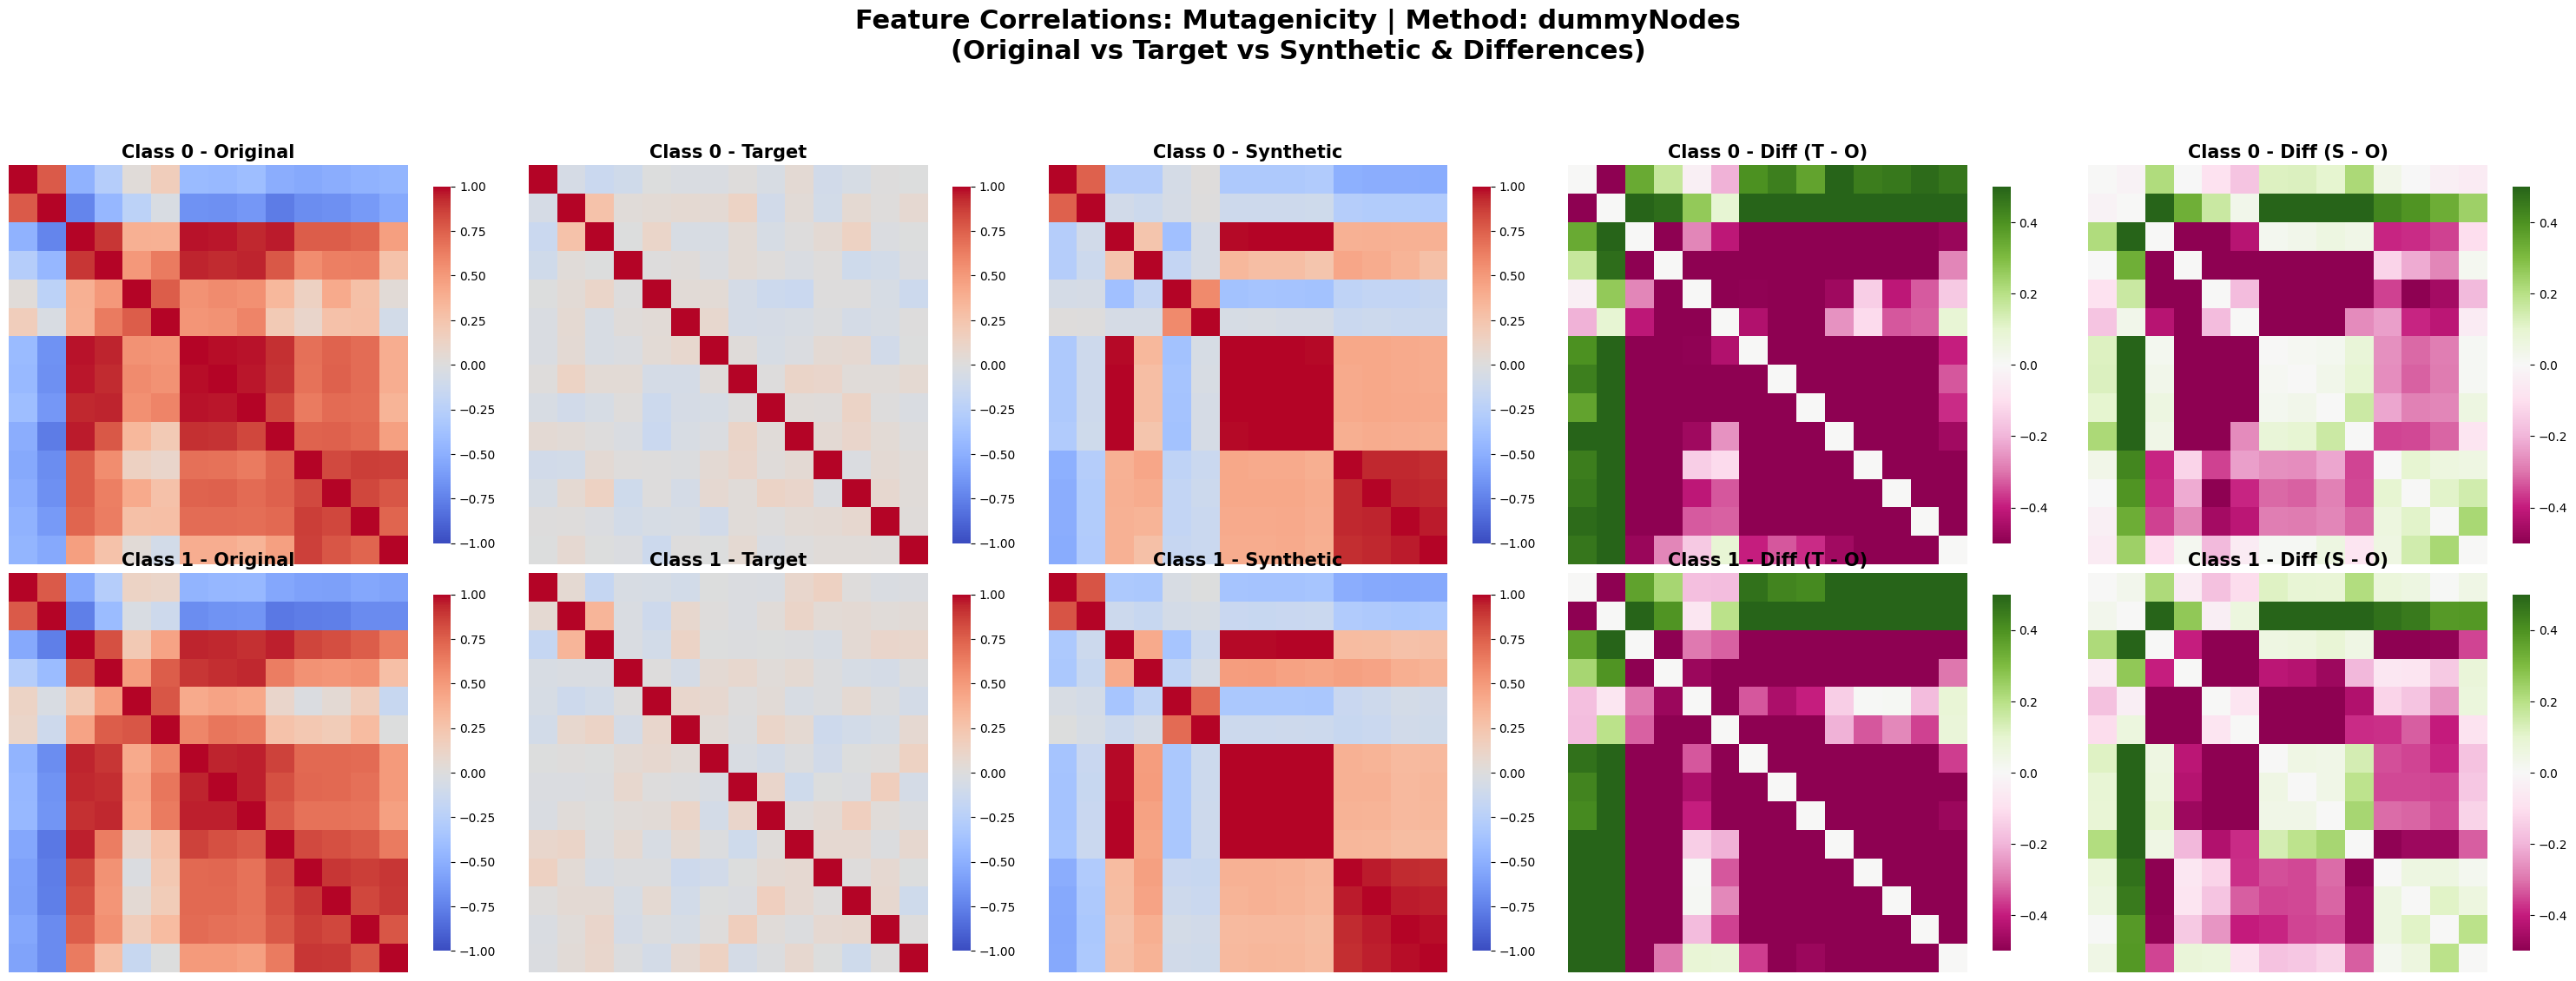


CORRELATION DIFFERENCES - METHOD: dummyNodes


,target_corr_diff,synth_corr_diff
Mutagenicity,0.556157,0.284716
MEAN,0.556157,0.284716


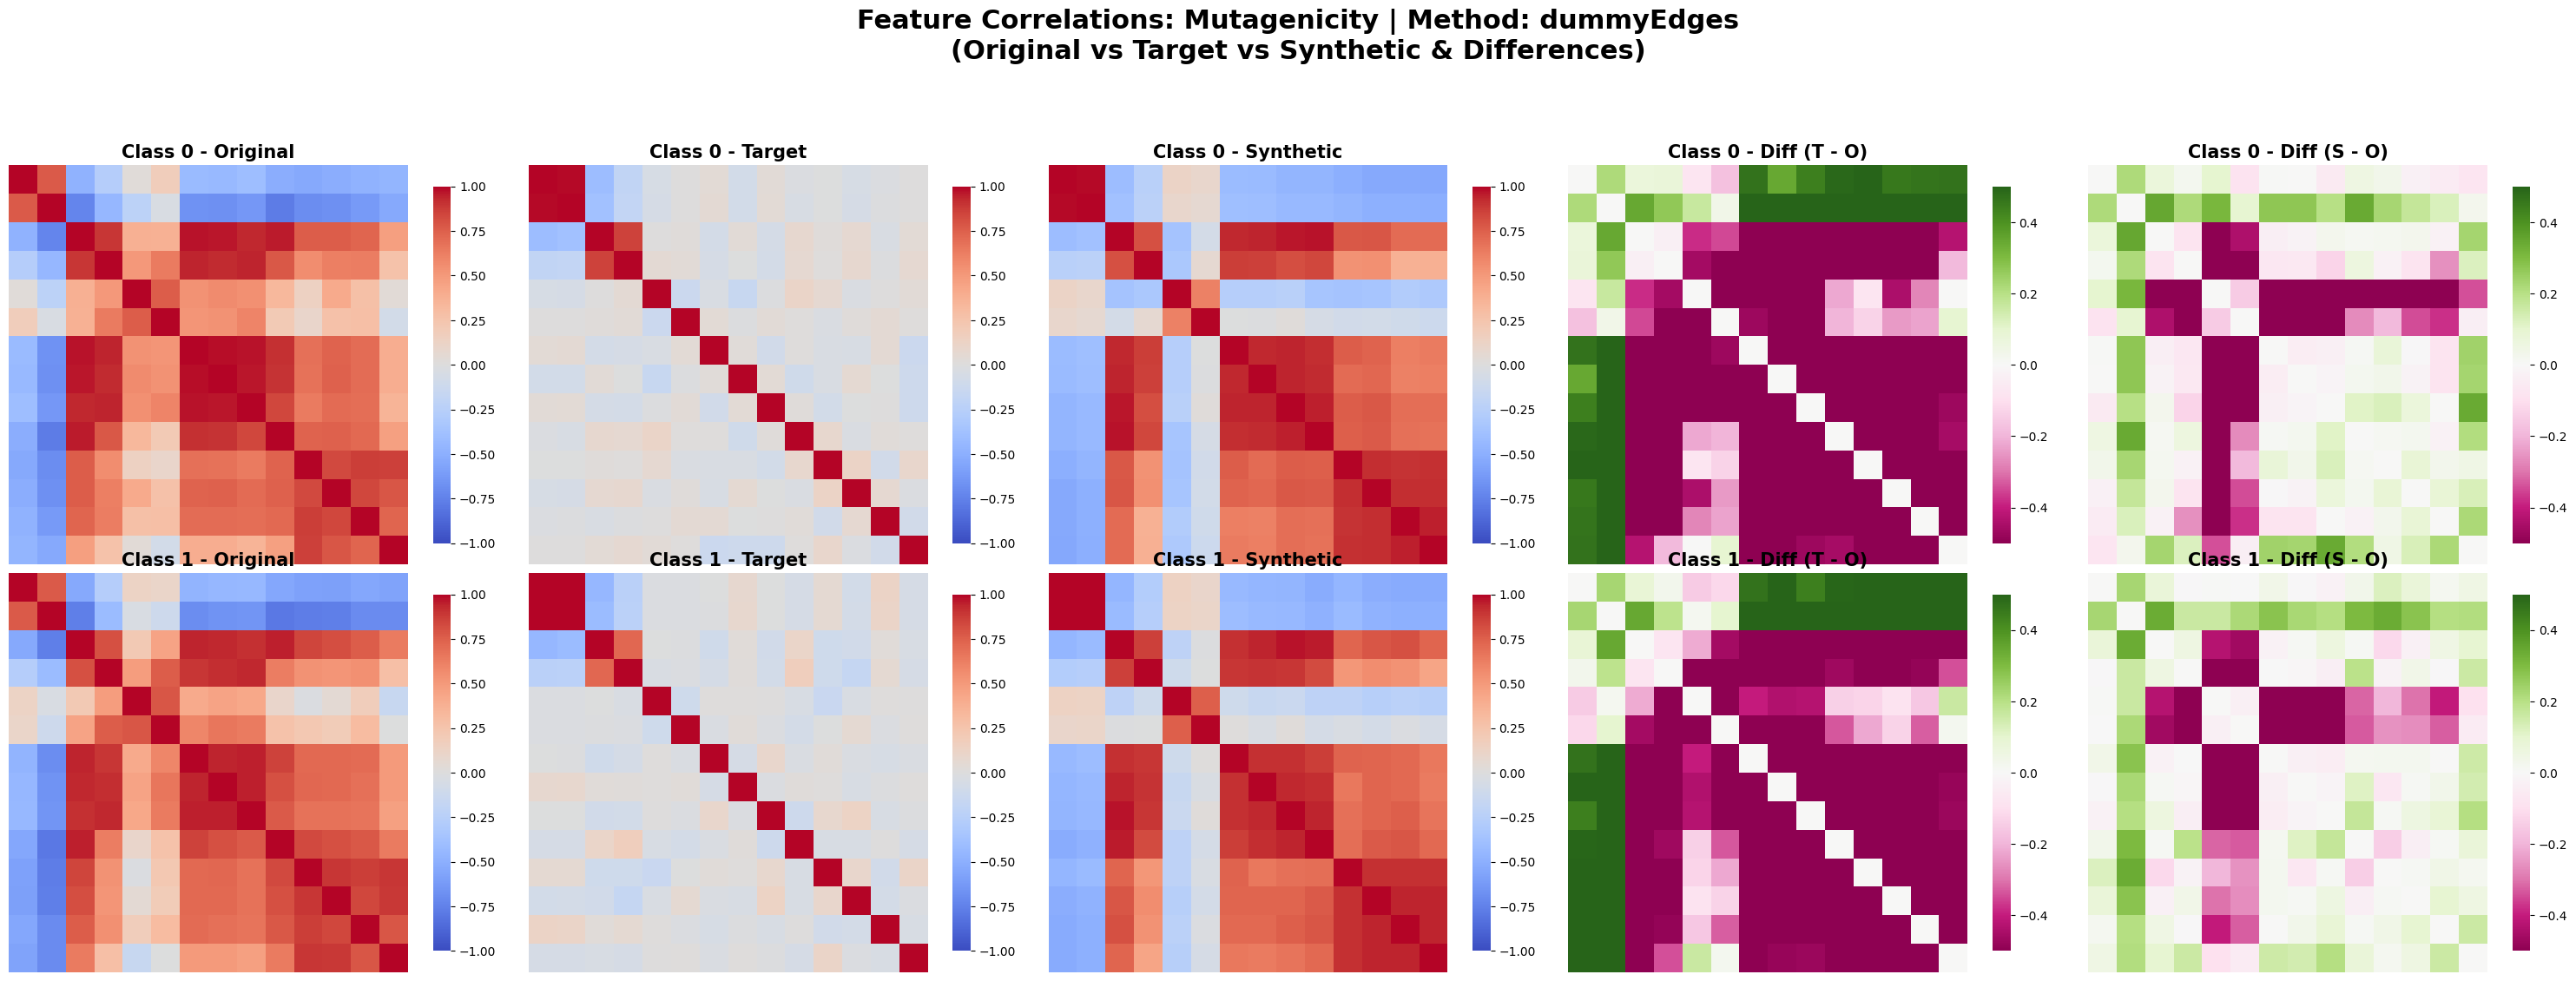


CORRELATION DIFFERENCES - METHOD: dummyEdges


,target_corr_diff,synth_corr_diff
Mutagenicity,0.527536,0.169008
MEAN,0.527536,0.169008


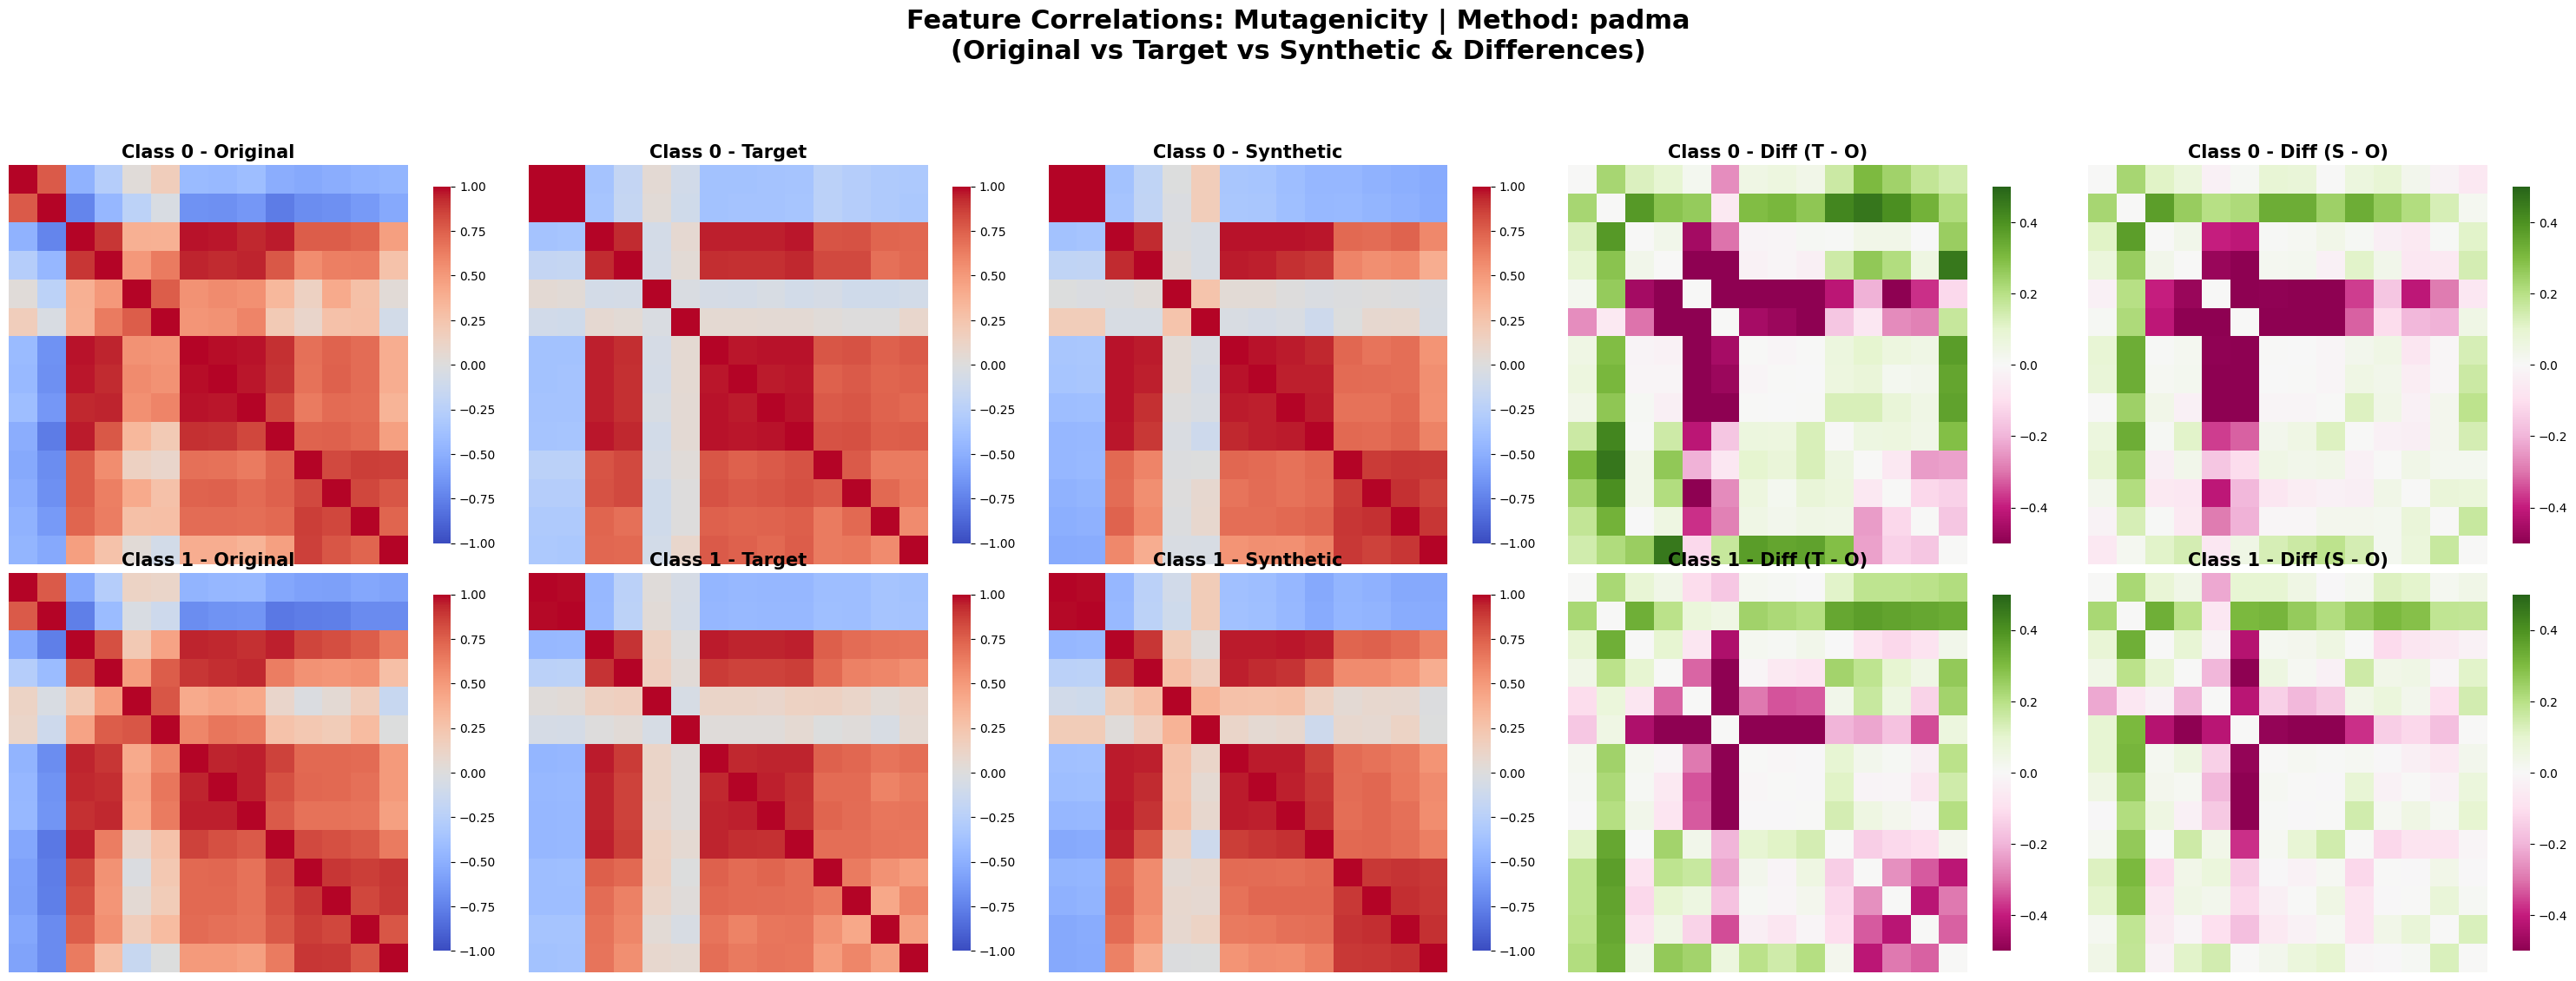


CORRELATION DIFFERENCES - METHOD: padma


,target_corr_diff,synth_corr_diff
Mutagenicity,0.182427,0.14336
MEAN,0.182427,0.14336


In [35]:
def plot_correlation_comparison(
    df_orig: pd.DataFrame,
    df_target: pd.DataFrame,
    df_synth: pd.DataFrame,
    dataset_name: str,
    method_name: str
) -> None:
    """Plots correlation heatmaps and differences for original, target, and synthetic data.
    
    Args:
        df_orig: Original dataset DataFrame
        df_target: Target dataset DataFrame
        df_synth: Synthetic dataset DataFrame
        dataset_name: Name of the dataset
        method_name: Name of the generation method
    """
    classes = [0, 1]
    n_classes = len(classes)
    
    # Use only variant_idx == 0 for plotting target/synth to be representative and clean
    df_target_var0 = df_target[df_target["variant_idx"] == 0] if not df_target.empty else df_target
    df_synth_var0 = df_synth[df_synth["variant_idx"] == 0] if not df_synth.empty else df_synth
    
    # 5-column layout: Original, Target, Synthetic, Target Diff (T - O), Synth Diff (S - O)
    fig, axes = plt.subplots(n_classes, 5, figsize=(30, 6 * n_classes))
    if n_classes == 1:
        axes = axes.reshape(1, 5)
        
    fig.suptitle(
        f"Feature Correlations: {dataset_name} | Method: {method_name}\n(Original vs Target vs Synthetic & Differences)",
        fontsize=22,
        fontweight="bold",
        y=0.99
    )
    
    heatmap_kwargs = {
        "center": 0,
        "annot": False,
        "square": True,
        "cbar_kws": {"shrink": 0.8},
        "xticklabels": False,
        "yticklabels": False
    }
    
    for i, class_id in enumerate(classes):
        orig_cls = df_orig[df_orig["class_id"] == class_id]
        target_cls = df_target_var0[df_target_var0["class_id"] == class_id] if not df_target_var0.empty else pd.DataFrame()
        synth_cls = df_synth_var0[df_synth_var0["class_id"] == class_id] if not df_synth_var0.empty else pd.DataFrame()
        
        if orig_cls.empty:
            # Skip class if original data is empty
            for col in range(5):
                axes[i, col].axis("off")
            continue
            
        corr_orig = orig_cls[TARGETED_FEATURES].corr().fillna(0)
        
        # 1. Original
        sns.heatmap(corr_orig, ax=axes[i, 0], cmap="coolwarm", vmin=-1, vmax=1, **heatmap_kwargs)
        axes[i, 0].set_title(f"Class {class_id} - Original", fontsize=15, fontweight="bold")
        
        # 2. Target
        if not target_cls.empty:
            corr_target = target_cls[TARGETED_FEATURES].corr().fillna(0)
            sns.heatmap(corr_target, ax=axes[i, 1], cmap="coolwarm", vmin=-1, vmax=1, **heatmap_kwargs)
            axes[i, 1].set_title(f"Class {class_id} - Target", fontsize=15, fontweight="bold")
            
            corr_diff_target = corr_target - corr_orig
            sns.heatmap(corr_diff_target, ax=axes[i, 3], cmap="PiYG", vmin=-0.5, vmax=0.5, **heatmap_kwargs)
            axes[i, 3].set_title(f"Class {class_id} - Diff (T - O)", fontsize=15, fontweight="bold")
        else:
            axes[i, 1].axis("off")
            axes[i, 3].axis("off")
            
        # 3. Synthetic
        if not synth_cls.empty:
            corr_synth = synth_cls[TARGETED_FEATURES].corr().fillna(0)
            sns.heatmap(corr_synth, ax=axes[i, 2], cmap="coolwarm", vmin=-1, vmax=1, **heatmap_kwargs)
            axes[i, 2].set_title(f"Class {class_id} - Synthetic", fontsize=15, fontweight="bold")
            
            corr_diff_synth = corr_synth - corr_orig
            sns.heatmap(corr_diff_synth, ax=axes[i, 4], cmap="PiYG", vmin=-0.5, vmax=0.5, **heatmap_kwargs)
            axes[i, 4].set_title(f"Class {class_id} - Diff (S - O)", fontsize=15, fontweight="bold")
        else:
            axes[i, 2].axis("off")
            axes[i, 4].axis("off")
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.94])
    plt.show()


def evaluate_correlation_distances(
    df_method: pd.DataFrame,
    method_name: str,
    plot_dataset: str = "MUTAG"
) -> None:
    """Evaluates and displays global targeted correlation differences for a single method.
    
    Args:
        df_method: The DataFrame filtered for the current method (and original data).
        method_name: The name of the method being evaluated.
        plot_dataset: The name of the dataset for which to plot correlation matrices.
    """
    method_rows = []
    
    for dataset in DATASET_NAMES:
        df_sub = df_method[df_method["dataset"] == dataset]
        df_orig = df_sub[df_sub["type"] == "original"]
        df_target = df_sub[df_sub["type"] == "target"]
        df_synth = df_sub[df_sub["type"] == "synthetic"]
        
        if df_orig.empty:
            continue
            
        # Plot correlation comparison (only for specified dataset and variant 0)
        if dataset == plot_dataset:
            plot_correlation_comparison(df_orig, df_target, df_synth, dataset, method_name)
            
        # Calculate global correlation MAE across classes and variants
        classes = [0, 1]
        
        # 1. Target correlation difference
        target_maes = []
        if not df_target.empty:
            for c_id in classes:
                df_orig_cls = df_orig[df_orig["class_id"] == c_id]
                if df_orig_cls.empty:
                    continue
                corr_orig = df_orig_cls[TARGETED_FEATURES].corr().fillna(0).values
                
                for v_idx in df_target["variant_idx"].unique():
                    df_target_var = df_target[(df_target["variant_idx"] == v_idx) & (df_target["class_id"] == c_id)]
                    if df_target_var.empty:
                        continue
                    corr_target = df_target_var[TARGETED_FEATURES].corr().fillna(0).values
                    mae = float(np.mean(np.abs(corr_target - corr_orig)))
                    target_maes.append(mae)
                    
        # 2. Synthetic correlation difference
        synth_maes = []
        if not df_synth.empty:
            for c_id in classes:
                df_orig_cls = df_orig[df_orig["class_id"] == c_id]
                if df_orig_cls.empty:
                    continue
                corr_orig = df_orig_cls[TARGETED_FEATURES].corr().fillna(0).values
                
                for v_idx in df_synth["variant_idx"].unique():
                    df_synth_var = df_synth[(df_synth["variant_idx"] == v_idx) & (df_synth["class_id"] == c_id)]
                    if df_synth_var.empty:
                        continue
                    corr_synth = df_synth_var[TARGETED_FEATURES].corr().fillna(0).values
                    mae = float(np.mean(np.abs(corr_synth - corr_orig)))
                    synth_maes.append(mae)
                    
        # Aggregate stats
        row = {"dataset": dataset}
        if target_maes:
            row["target_corr_diff"] = float(np.mean(target_maes))
        else:
            row["target_corr_diff"] = float("nan")
            
        if synth_maes:
            row["synth_corr_diff"] = float(np.mean(synth_maes))
        else:
            row["synth_corr_diff"] = float("nan")
            
        method_rows.append(row)
        
    if method_rows:
        df_res = pd.DataFrame(method_rows)
        df_res.set_index("dataset", inplace=True)
        
        # Calculate MEAN rows for both difference metrics
        mean_row = df_res.mean(numeric_only=True)
        mean_row.name = "MEAN"
        df_res = pd.concat([df_res, mean_row.to_frame().T])
        
        print("\n" + "=" * 100)
        print(f"CORRELATION DIFFERENCES - METHOD: {method_name}")
        print("=" * 100)
        with pd.option_context("display.max_columns", None):
            display(df_res)


# Execute global correlation evaluation for each method
for method in METHODS:
    df_method_subset = df[(df["method"] == method) | (df["type"] == "original")]
    
    if df_method_subset[df_method_subset["method"] == method].empty:
        continue
        
    evaluate_correlation_distances(df_method_subset, method, plot_dataset="Mutagenicity")